In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/cleaned_data.csv")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Year,Month,Month_Name
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,December
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,December
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,December
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,December
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,December


In [3]:
df['TotalSales'] = df['Quantity'] * df['UnitPrice']

In [4]:
total_revenue = df['TotalSales'].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 8887208.894000001


In [5]:
total_orders = df['InvoiceNo'].nunique()
print("Total Orders:", total_orders)

Total Orders: 18532


In [6]:
total_customers = df['CustomerID'].nunique()
print("Total Customers:", total_customers)

Total Customers: 4338


In [7]:
monthly_sales = df.groupby('Month_Name')['TotalSales'].sum().sort_values()
monthly_sales

Month_Name
February      446084.920
April         468374.331
January       568101.310
March         594081.760
July          598962.901
August        644051.040
June          660046.050
May           677355.150
September     950690.202
October      1035642.450
December     1087613.170
November     1156205.610
Name: TotalSales, dtype: float64

In [8]:
top_products = df.groupby('Description')['TotalSales'].sum().sort_values(ascending=False).head(10)
top_products

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68785.23
ASSORTED COLOUR BIRD ORNAMENT          56413.03
Manual                                 53419.93
RABBIT NIGHT LIGHT                     51251.24
Name: TotalSales, dtype: float64

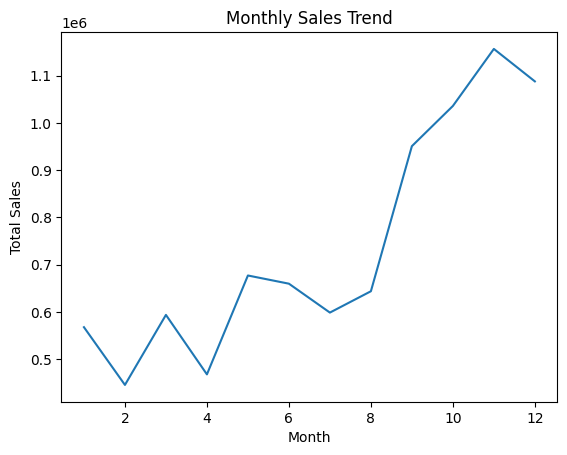

In [9]:
import matplotlib.pyplot as plt

monthly_sales = df.groupby('Month')['TotalSales'].sum().sort_index()

plt.figure()
monthly_sales.plot(kind='line')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

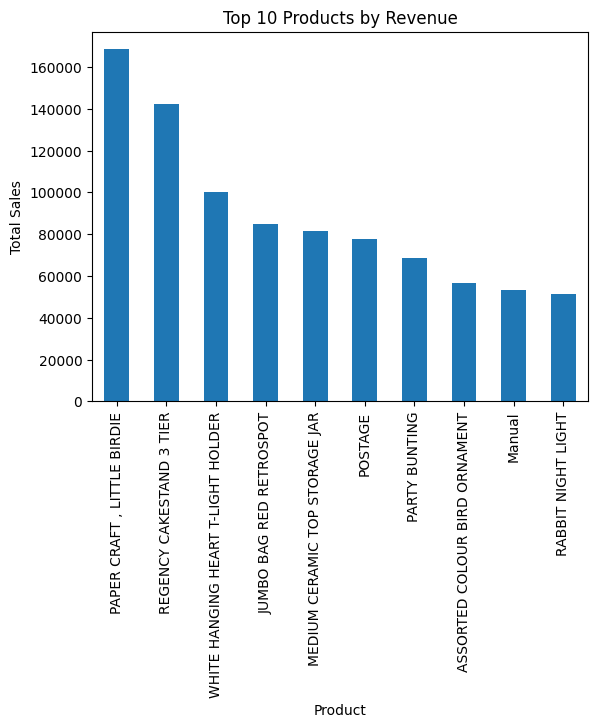

In [10]:
top_products = df.groupby('Description')['TotalSales'].sum().sort_values(ascending=False).head(10)

plt.figure()
top_products.plot(kind='bar')
plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.xticks(rotation=90)
plt.show()

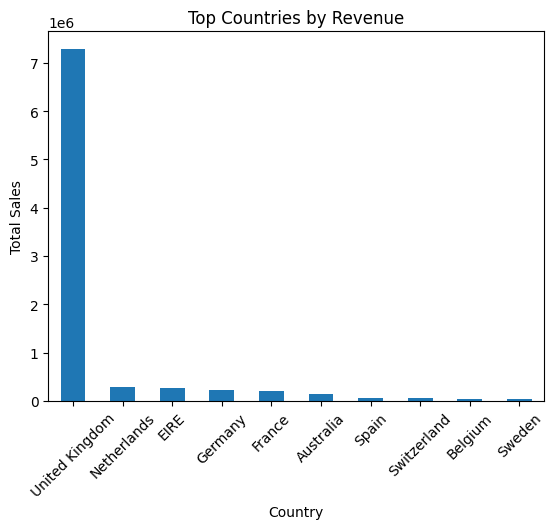

In [11]:
country_sales = df.groupby('Country')['TotalSales'].sum().sort_values(ascending=False).head(10)

plt.figure()
country_sales.plot(kind='bar')
plt.title("Top Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

In [12]:
print("Total Revenue:", total_revenue)
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)

Total Revenue: 8887208.894000001
Total Orders: 18532
Total Customers: 4338


KeyError: 'Category'

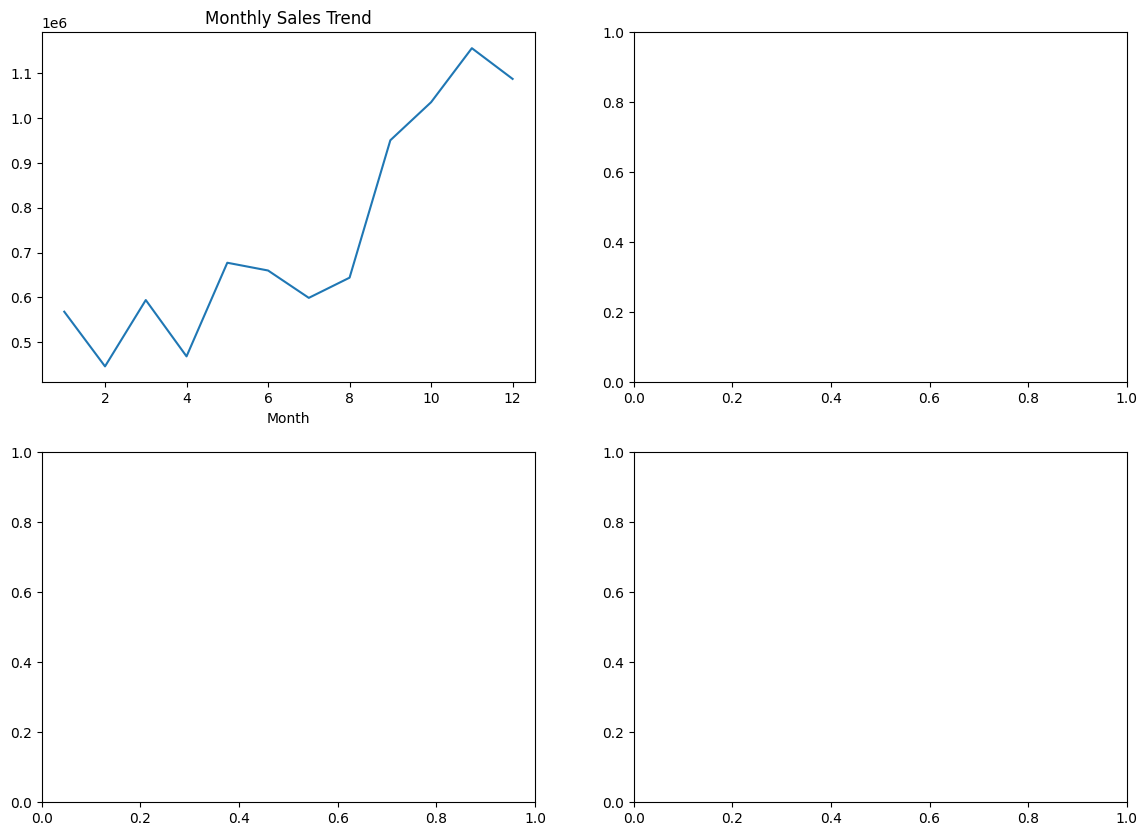

In [13]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(14,10))

# 1️⃣ Monthly Sales Trend
monthly_sales.plot(ax=axs[0,0])
axs[0,0].set_title("Monthly Sales Trend")

# 2️⃣ Sales by Category
category_sales = df.groupby("Category")["TotalSales"].sum()
category_sales.plot(kind='bar', ax=axs[0,1])
axs[0,1].set_title("Sales by Category")

# 3️⃣ Sales by Region
region_sales = df.groupby("Region")["TotalSales"].sum()
region_sales.plot(kind='bar', ax=axs[1,0])
axs[1,0].set_title("Sales by Region")

# 4️⃣ Profit by Category
category_profit = df.groupby("Category")["Profit"].sum()
category_profit.plot(kind='bar', ax=axs[1,1])
axs[1,1].set_title("Profit by Category")

plt.tight_layout()
plt.show()

In [ ]:
monthly_sales = df.groupby('Month')['TotalSales'].sum().sort_index()

NameError: name 'df' is not defined

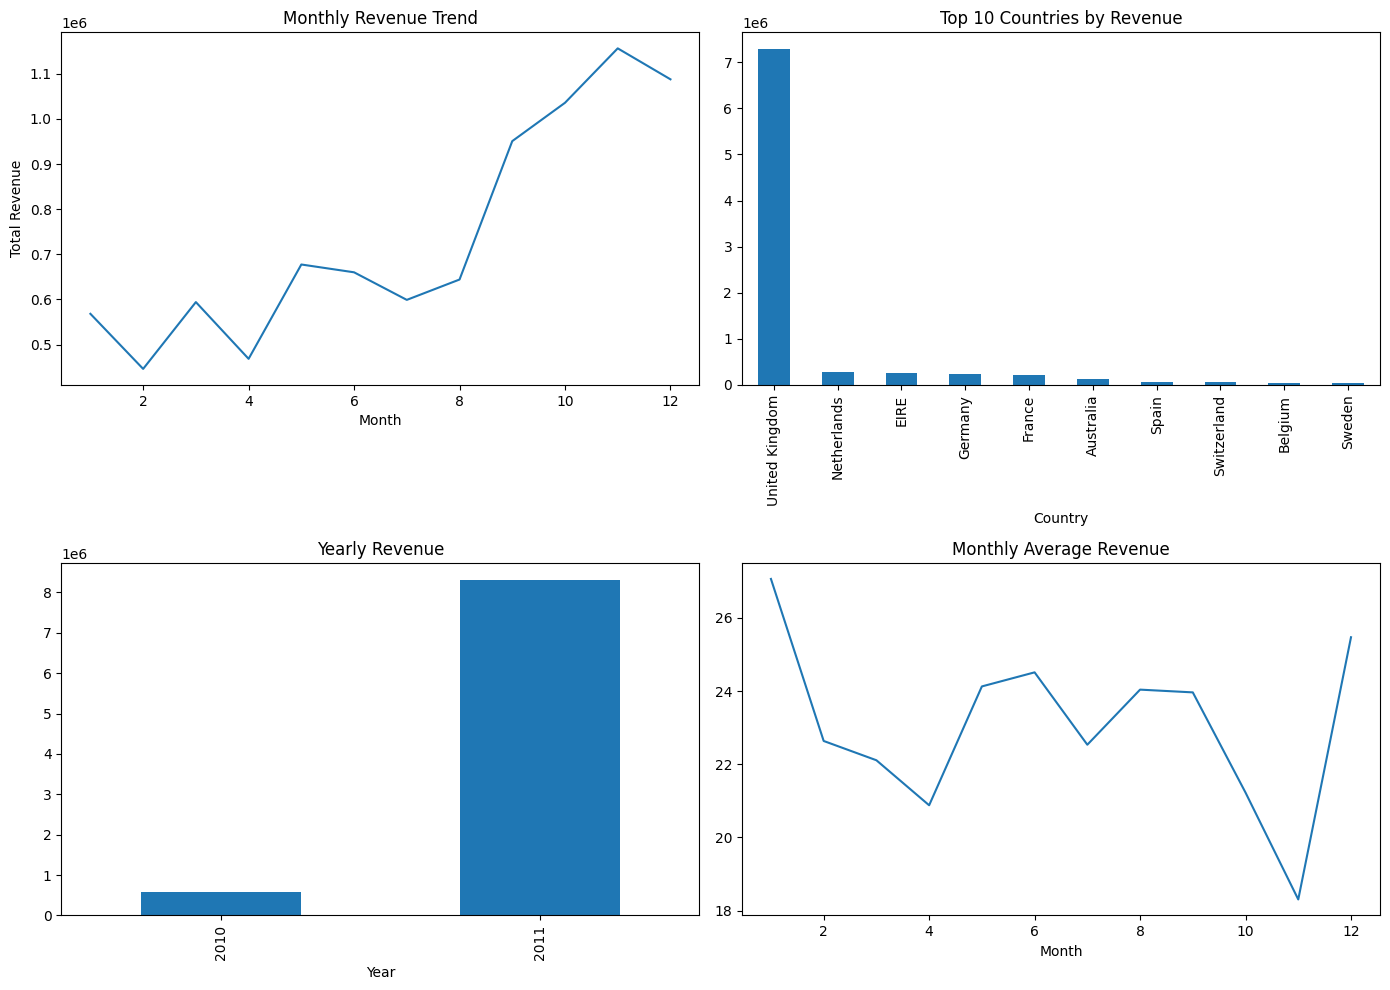

In [14]:
import matplotlib.pyplot as plt

# ---- Monthly Sales Trend ----
monthly_sales = df.groupby("Month")["Revenue"].sum().sort_index()

# ---- Sales by Country (Top 10) ----
country_sales = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10)

# ---- Yearly Revenue ----
yearly_sales = df.groupby("Year")["Revenue"].sum()

# ---- Monthly Average Revenue ----
monthly_avg = df.groupby("Month")["Revenue"].mean().sort_index()

# ---- Create Dashboard ----
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# 1️⃣ Monthly Revenue Trend
monthly_sales.plot(ax=axs[0,0])
axs[0,0].set_title("Monthly Revenue Trend")
axs[0,0].set_xlabel("Month")
axs[0,0].set_ylabel("Total Revenue")

# 2️⃣ Top 10 Countries by Revenue
country_sales.plot(kind="bar", ax=axs[0,1])
axs[0,1].set_title("Top 10 Countries by Revenue")

# 3️⃣ Yearly Revenue
yearly_sales.plot(kind="bar", ax=axs[1,0])
axs[1,0].set_title("Yearly Revenue")

# 4️⃣ Monthly Average Revenue
monthly_avg.plot(ax=axs[1,1])
axs[1,1].set_title("Monthly Average Revenue")

plt.tight_layout()
plt.show()